In [1]:
%matplotlib inline

In [2]:
from pyprojroot import here
import sys
sys.path.insert(0, str(here()))

In [3]:
from src.download_utils import load_download_bounds
from src.viewshed import render_viewshed_dashboard, create_altitude_visibility_table, calculate_visibility_percentiles

In [4]:
region, _ = load_download_bounds()

In [5]:
center_x = (region.west_m + region.east_m) / 2.0
center_y = (region.south_m + region.north_m) / 2.0

In [6]:
dem_file = here() / "data" / "digital_elevation_model" / "dem_90m.tif"

In [7]:
render_viewshed_dashboard(dem_file, center_x, center_y, 500.0)

interactive(children=(IntSlider(value=0, continuous_update=False, description='dx (km):', layout=Layout(width=…

In [8]:
table_10, total_horizons_10 = create_altitude_visibility_table(
    region,
    dem_file,
    grid_size=10,
    max_dist_km=1000.0,
    return_total_horizons=True,
 )
table_10

,Observer Altitude,Min Horizon (km),Max Horizon (km),Average Horizon (km),P90 Horizon (km),P95 Horizon (km),P99 Horizon (km),Sample Count
0,"< 3,000m",22.7,478.2,199.3,318.1,332.4,399.6,63
1,"3,000m - 4,000m",320.5,394.5,349.6,383.8,389.1,393.4,4
2,"4,000m - 5,000m",324.9,409.1,370.3,405.7,408.0,408.9,14
3,"> 5,000m",362.5,453.3,404.2,432.5,437.7,450.2,19
4,TOTAL (All Region Combined),22.7,478.2,268.2,409.1,419.2,453.6,100


This is the theoretical limit for maximum distance visible from Khumbu region.

Practically, it might be very very less due to fog.

Higher altitudes have higher visible distance.

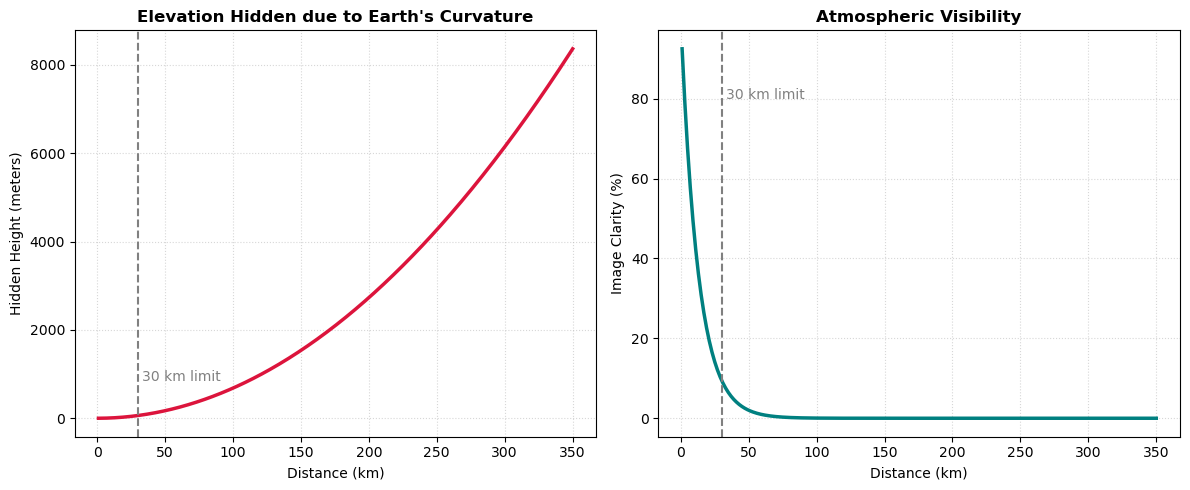

In [ ]:
import numpy as np
from src.physics import plot_horizon_limit_proof

distances_km = np.arange(1.0, 351.0, 1.0)
plot_horizon_limit_proof(distances_km)

As distance increases, haze makes mountains fade. At the same time, Earth's curvature hides the bottom of far-away mountains, making them look flat. 

This is why we limit our search database to **30 km**.

At 30km, haze has already reduced visibility to under 10%.